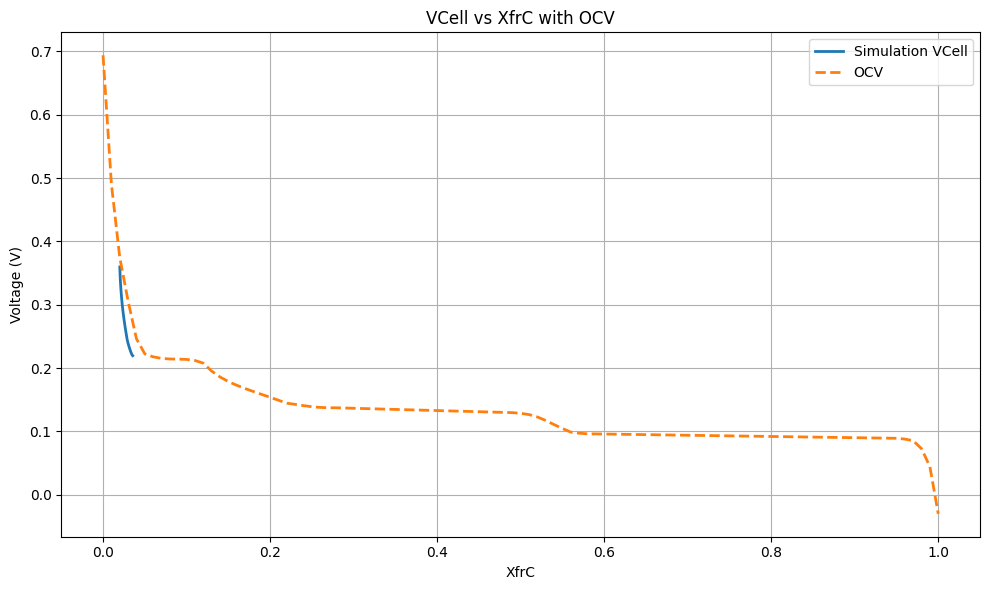

In [9]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD SIMULATION OUTPUT
# ============================================================

file_path = "../bin/anode_concentrations.txt"

with open(file_path, 'r') as f:
    lines = f.readlines()
    #read lines starting at line 102:
    lines = lines[27:]

pattern = re.compile(
    r"timestep:\s*(\d+).*?VCell\s*=\s*([-eE0-9.]+),.*?XfrC_avg\s*=\s*([-eE0-9.]+)"
)

data = []

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        XfrC = float(match.group(3))
        vcell = abs(float(match.group(2)))

        data.append((timestep, vcell, XfrC))

df = pd.DataFrame(data, columns=["timestep", "vcell", "XfrC"])

# Optional filtering
# df = df[df["timestep"] % 500 != 0]
# df = df[df["timestep"] != 0]

# ============================================================
# STEP 2: LOAD LFP OCV TABLE
# ============================================================

ticks = np.loadtxt("../inputs/materials/C_Li_X_101.txt")
ocv = np.loadtxt("../inputs/materials/C_Li_O3_101.txt")

# Convert chemical potential to OCV
# ocv = -mu + 3.4

# ============================================================
# STEP 3: INTERPOLATE OCV AT SIMULATION XfrC VALUES
# ============================================================

df["ocv"] = np.interp(df["XfrC"], ticks, ocv)

# ============================================================
# STEP 4: PLOT
# ============================================================

plt.figure(figsize=(10,6))

# Simulation voltage
plt.plot(
    df["XfrC"],
    df["vcell"],
    linewidth=2,
    label="Simulation VCell"
)

# OCV curve
plt.plot(
    ticks,
    ocv,
    '--',
    linewidth=2,
    label="OCV"
)

# Optional: interpolated OCV sampled at simulation points
# plt.plot(df["XfrC"], df["ocv"], 'o', markersize=3)

plt.xlabel("XfrC")
plt.ylabel("Voltage (V)")
plt.title("VCell vs XfrC with OCV")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD SIMULATION OUTPUT
# ============================================================

file_path = "../bin/cathode_concentrations.txt"

# with open(file_path, 'r') as f:
#     lines = f.readlines()

with open(file_path, 'r') as f:
    lines = f.readlines()[7:]   # start at line 87

pattern = re.compile(
    r"timestep:\s*(\d+).*?VCell\s*=\s*([-eE0-9.]+),.*?XfrC_avg\s*=\s*([-eE0-9.]+)"
)

data = []

for line in lines:
    match = pattern.search(line)
    if match:
        timestep = int(match.group(1))
        XfrC = float(match.group(3))
        vcell = abs(float(match.group(2)))

        data.append((timestep, vcell, XfrC))

df = pd.DataFrame(data, columns=["timestep", "vcell", "XfrC"])

# Optional filtering
# df = df[df["timestep"] % 500 != 0]
# df = df[df["timestep"] != 0]

# ============================================================
# STEP 2: DEFINE OCV FUNCTION
# ============================================================

def ocv_function(c):
    return (
        1.095 * c * c
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )

# Generate smooth OCV curve
c_vals = np.linspace(0.3, 1.0, 500)
ocv_vals = ocv_function(c_vals)

# Interpolated OCV at simulation points
df["ocv"] = ocv_function(df["XfrC"])

# ============================================================
# STEP 3: PLOT
# ============================================================

plt.figure(figsize=(10,6))

# Simulation voltage
plt.plot(
    df["XfrC"],
    df["vcell"],
    linewidth=2,
    label="Simulation VCell"
)

# Analytical OCV curve
plt.plot(
    c_vals,
    ocv_vals,
    '--',
    linewidth=2,
    label="OCV Curve"
)

plt.xlabel("XfrC")
plt.ylabel("Voltage (V)")
plt.title("VCell vs XfrC with OCV")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()